# Diabetic Patient Readmission — Ensemble Models, Explainability & Fairness

Early hospital readmission (within 30 days of discharge) is a costly and
partly preventable outcome. This case study uses the UCI **Diabetes 130-US
hospitals** dataset (101,766 encounters, 1999-2008) to predict which
diabetic patients are readmitted within 30 days, then goes one step further
than a typical classification exercise:

- **SHAP** explains *why* the model predicts what it predicts.
- A **fairness audit** checks whether the model's error rates differ across
  race, gender and age — a question that matters a great deal before any
  clinical model like this could be used to prioritize care.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## Load data & define the target

In [2]:
hosp = fetch_ucirepo(id=296)
df = hosp.data.features.copy()
df["readmitted"] = hosp.data.targets["readmitted"].values
df["target"] = (df["readmitted"] == "<30").astype(int)

print(f"Shape: {df.shape}")
vc = df["target"].value_counts()
print(f"Readmitted <30 days: {vc[1]} ({100 * vc[1] / len(df):.1f}%) of {len(df)}")

Shape: (101766, 49)
Readmitted <30 days: 11357 (11.2%) of 101766


## Exploratory analysis

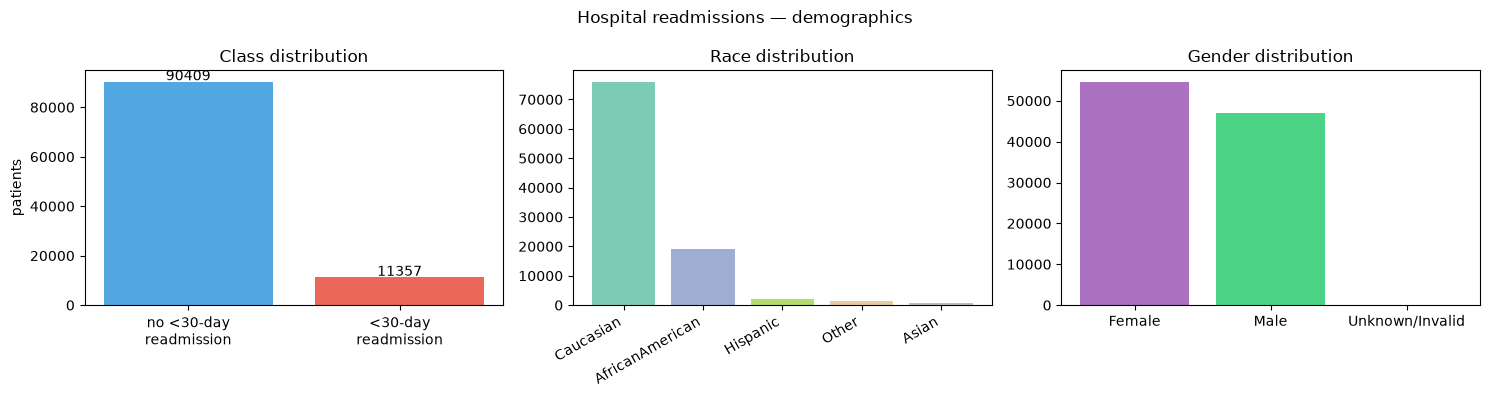

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(["no <30-day\nreadmission", "<30-day\nreadmission"], vc.values,
            color=["#3498db", "#e74c3c"], alpha=0.85)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 500, str(v), ha="center")
axes[0].set_title("Class distribution")
axes[0].set_ylabel("patients")

rc = df["race"].value_counts()
axes[1].bar(rc.index, rc.values, color=plt.cm.Set2(np.linspace(0, 1, len(rc))), alpha=0.85)
axes[1].set_title("Race distribution")
axes[1].set_xticklabels(rc.index, rotation=30, ha="right")

gc = df["gender"].value_counts()
axes[2].bar(gc.index, gc.values, color=["#9b59b6", "#2ecc71"], alpha=0.85)
axes[2].set_title("Gender distribution")
plt.suptitle("Hospital readmissions — demographics")
plt.tight_layout()
plt.savefig("figures/demographics_overview.png", dpi=130, bbox_inches="tight")
plt.show()

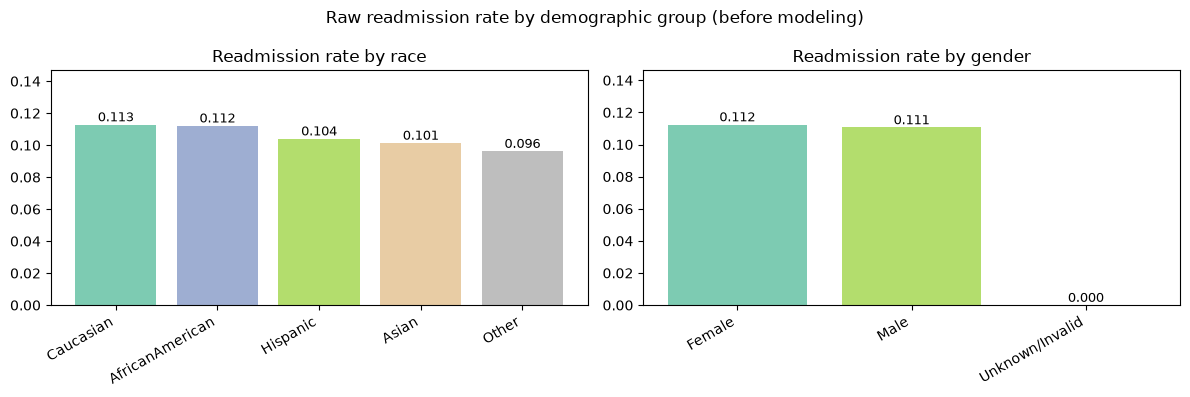

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["race", "gender"]):
    rate = df.groupby(col)["target"].mean().sort_values(ascending=False)
    ax.bar(rate.index, rate.values, color=plt.cm.Set2(np.linspace(0, 1, len(rate))), alpha=0.85)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
    ax.set_title(f"Readmission rate by {col}")
    ax.set_xticklabels(rate.index, rotation=30, ha="right")
    ax.set_ylim(0, rate.max() * 1.3)
plt.suptitle("Raw readmission rate by demographic group (before modeling)")
plt.tight_layout()
plt.savefig("figures/readmission_rate_by_group.png", dpi=130, bbox_inches="tight")
plt.show()

## Preprocessing

`race`, `gender` and `age` are kept aside as **sensitive attributes** for the
fairness audit later — they are excluded from being treated as ordinary
features only in the sense that we track them separately; the underlying
columns still take part in modeling like everything else, since a model that
"forgets" a column can still discriminate through correlated proxies
(this is exactly what the counterfactual check further down tests for).
Columns with very high missingness (`weight`, `payer_code`,
`medical_specialty`) are dropped instead of imputed.

In [5]:
sensitive_cols = ["race", "gender", "age"]
drop_cols = ["readmitted", "target", "encounter_id", "patient_nbr",
             "weight", "payer_code", "medical_specialty"]

df_prep = df.replace("?", np.nan)
sensitive = df_prep[sensitive_cols].copy()
feat_cols = [c for c in df_prep.columns if c not in drop_cols]
X = df_prep[feat_cols].copy()
y = df["target"].values

cat_cols = X.select_dtypes(include="object").columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
X = X.values.astype(float)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
sens_test = sensitive.iloc[idx_test].reset_index(drop=True)

print(f"Train: {X_train.shape}, test: {X_test.shape}")
print(f"Dropped for missingness/leakage: {drop_cols}")

Train: (81412, 44), test: (20354, 44)
Dropped for missingness/leakage: ['readmitted', 'target', 'encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']


## Models

Three tree-ensemble classifiers with fixed, literature-typical
hyperparameters (no exhaustive grid search — the point here is the
explainability and fairness analysis, not squeezing out another percent of
accuracy). `scale_pos_weight` / `class_weight="balanced"` compensate for the
11% positive-class rate.

In [6]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "LightGBM": lgb.LGBMClassifier(
        num_leaves=63, learning_rate=0.05, min_child_samples=50,
        scale_pos_weight=pos_weight, verbose=-1, random_state=RANDOM_STATE,
    ),
    "XGBoost": xgb.XGBClassifier(
        max_depth=6, learning_rate=0.1, subsample=0.8,
        scale_pos_weight=pos_weight, verbosity=0, eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
}
for m in models.values():
    m.fit(X_train, y_train)
print("Trained:", list(models.keys()))

Trained: ['Random Forest', 'LightGBM', 'XGBoost']


## Performance

In [7]:
rows = []
for name, model in models.items():
    yp = model.predict(X_test)
    rows.append({
        "model": name,
        "recall": recall_score(y_test, yp),
        "precision": precision_score(y_test, yp),
        "f1": f1_score(y_test, yp),
        "balanced_accuracy": balanced_accuracy_score(y_test, yp),
    })
perf = pd.DataFrame(rows).set_index("model")
print(perf.round(4).to_string())

               recall  precision      f1  balanced_accuracy
model                                                      
Random Forest  0.5288     0.1909  0.2806             0.6237
LightGBM       0.5852     0.1881  0.2847             0.6340
XGBoost        0.5627     0.1830  0.2762             0.6236


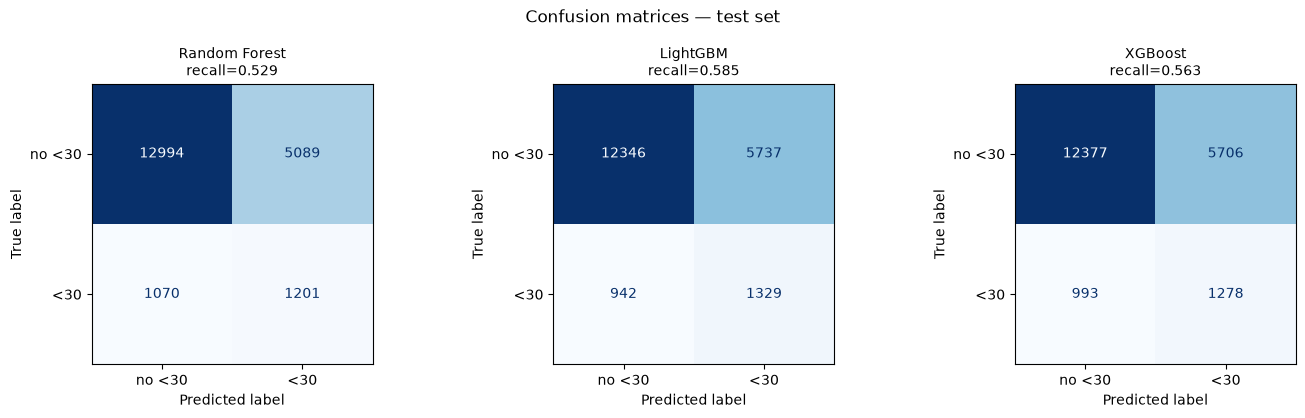

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (name, model) in zip(axes, models.items()):
    yp = model.predict(X_test)
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=["no <30", "<30"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nrecall={recall_score(y_test, yp):.3f}", fontsize=10)
plt.suptitle("Confusion matrices — test set")
plt.tight_layout()
plt.savefig("figures/confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

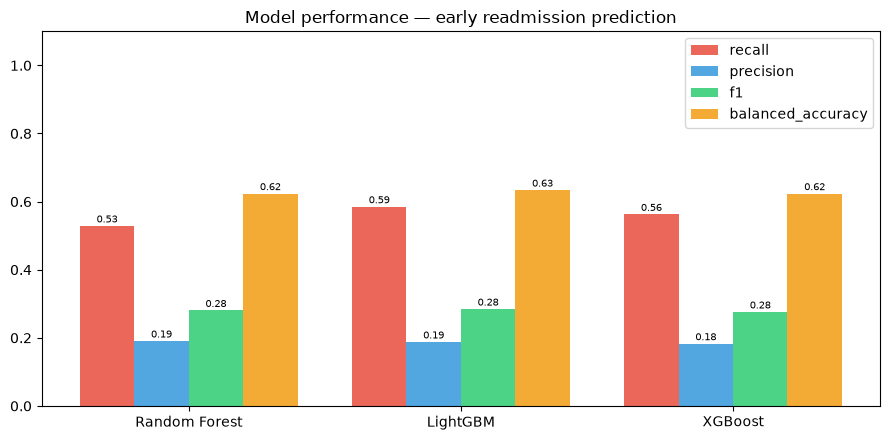

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(perf))
width = 0.2
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
for i, (metric, color) in enumerate(zip(perf.columns, colors)):
    bars = ax.bar(x + (i - 1.5) * width, perf[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(perf.index)
ax.set_ylim(0, 1.1)
ax.set_title("Model performance — early readmission prediction")
ax.legend()
plt.tight_layout()
plt.savefig("figures/performance_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## Explainability — SHAP

Recall is modest across all three models (56-59%) — expected for a hard,
noisy real-world target. Before trusting *any* of these models, we need to
know what's actually driving predictions.

In [10]:
best_name = perf["f1"].idxmax()
best_model = models[best_name]
print(f"Best model by F1: {best_name}")

explainer = shap.TreeExplainer(best_model)
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_test.shape[0], min(2000, X_test.shape[0]), replace=False)
X_shap = X_test[sample_idx]
sv = explainer.shap_values(X_shap)
if isinstance(sv, list):
    sv = sv[1]
shap_exp = shap.Explanation(values=sv, data=X_shap, feature_names=feat_cols)

mean_abs = np.abs(sv).mean(axis=0)
top_feats = pd.Series(mean_abs, index=feat_cols).sort_values(ascending=False).head(5)
print("\nTop 5 SHAP features:")
print(top_feats.round(4).to_string())

Best model by F1: LightGBM



Top 5 SHAP features:
number_inpatient            0.3017
discharge_disposition_id    0.2377
diag_1                      0.1123
number_diagnoses            0.0581
diag_3                      0.0512


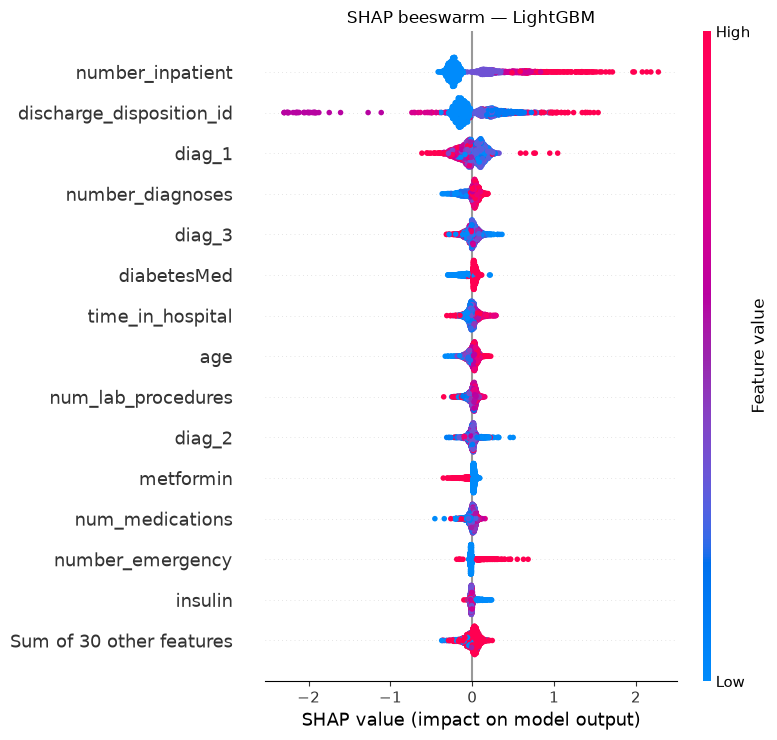

In [11]:
plt.figure(figsize=(9, 7))
shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title(f"SHAP beeswarm — {best_name}")
plt.tight_layout()
plt.savefig("figures/shap_beeswarm.png", dpi=130, bbox_inches="tight")
plt.show()

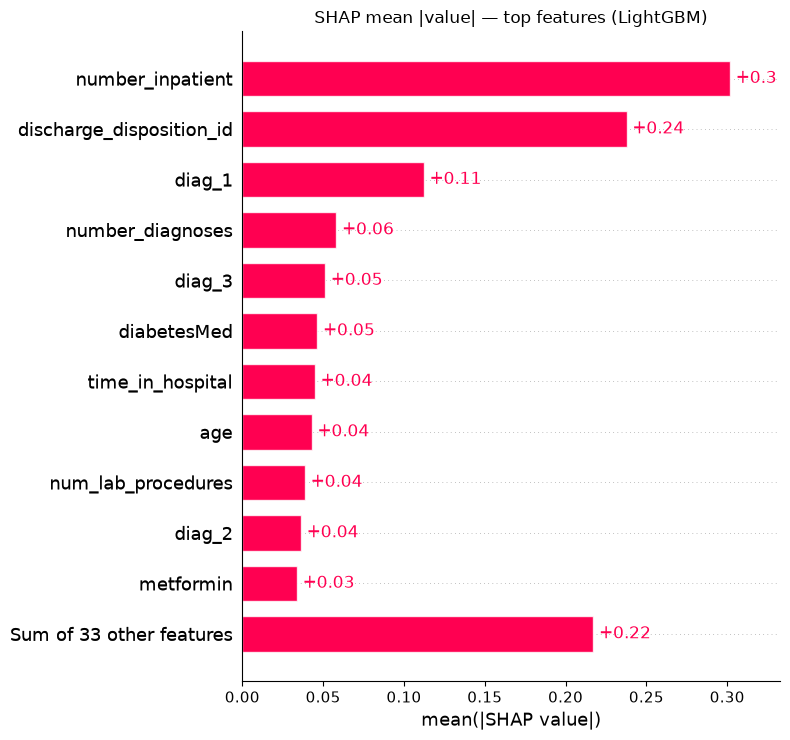

In [12]:
plt.figure(figsize=(8, 5))
shap.plots.bar(shap_exp, max_display=12, show=False)
plt.title(f"SHAP mean |value| — top features ({best_name})")
plt.tight_layout()
plt.savefig("figures/shap_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

## Fairness audit — equal opportunity

`number_inpatient` (prior hospitalizations) and `discharge_disposition_id`
dominate the SHAP ranking — clinically sensible, and neither is a protected
attribute. That's reassuring, but it doesn't guarantee fair *outcomes*: a
model can pick up race or age indirectly through features correlated with
them. The **equal opportunity** metric checks whether recall (true positive
rate) is similar across protected groups — if it isn't, the model catches
readmission risk less reliably for some groups than others.

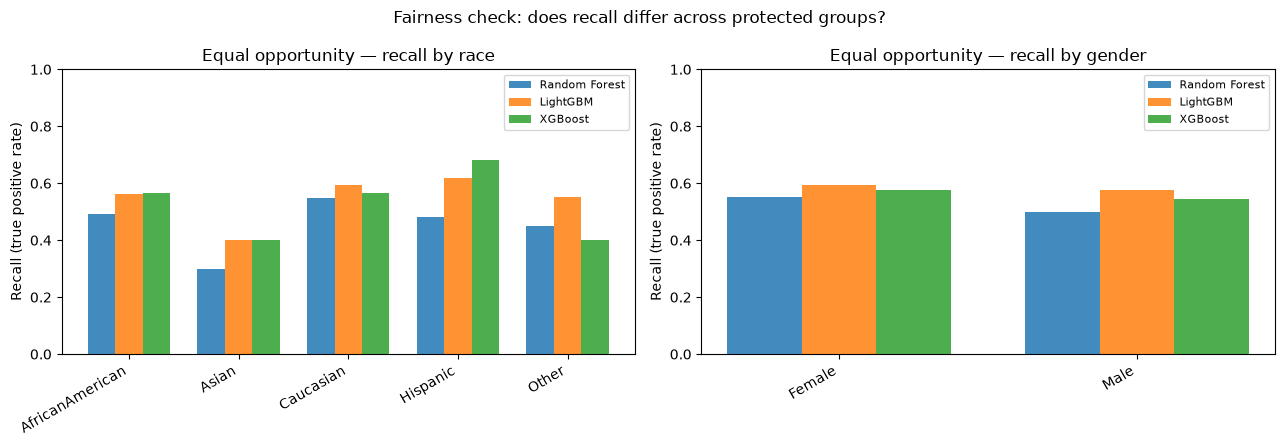

Recall by race:
  Random Forest: AfricanAmerican=0.493, Asian=0.300, Caucasian=0.547, Hispanic=0.480, Other=0.450
  LightGBM: AfricanAmerican=0.562, Asian=0.400, Caucasian=0.595, Hispanic=0.620, Other=0.550
  XGBoost: AfricanAmerican=0.565, Asian=0.400, Caucasian=0.567, Hispanic=0.680, Other=0.400
Recall by gender:
  Random Forest: Female=0.552, Male=0.500
  LightGBM: Female=0.593, Male=0.576
  XGBoost: Female=0.577, Male=0.545


In [13]:
def recall_per_group(model, group_col, values):
    yp = model.predict(X_test)
    out = {}
    for g in values:
        mask = sens_test[group_col].values == g
        if mask.sum() == 0 or y_test[mask].sum() == 0:
            continue
        out[g] = recall_score(y_test[mask], yp[mask])
    return out

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fairness_summary = {}
for ax, col in zip(axes, ["race", "gender"]):
    values = sorted(sens_test[col].dropna().unique())
    all_recalls = {name: recall_per_group(m, col, values) for name, m in models.items()}
    fairness_summary[col] = all_recalls
    width = 0.25
    x = np.arange(len(values))
    for i, (name, recalls) in enumerate(all_recalls.items()):
        vals = [recalls.get(g, 0) for g in values]
        ax.bar(x + (i - 1) * width, vals, width, label=name, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(values, rotation=30, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Recall (true positive rate)")
    ax.set_title(f"Equal opportunity — recall by {col}")
    ax.legend(fontsize=8)
plt.suptitle("Fairness check: does recall differ across protected groups?")
plt.tight_layout()
plt.savefig("figures/fairness_equal_opportunity.png", dpi=130, bbox_inches="tight")
plt.show()

for col, recalls in fairness_summary.items():
    print(f"Recall by {col}:")
    for name, r in recalls.items():
        print(f"  {name}: " + ", ".join(f"{g}={v:.3f}" for g, v in r.items()))

## Counterfactual check — does the model use race directly?

If recall differs by race, one useful follow-up question is whether the
model is using the `race` feature directly, or whether the gap comes from
correlated features instead. Overwriting every test row's `race` with the
majority value (`Caucasian`) and re-predicting isolates the *direct* effect
of that one column.

In [14]:
race_idx = feat_cols.index("race")
le_race = encoders["race"]
caucasian_code = le_race.transform(["Caucasian"])[0]
X_test_cf = X_test.copy()
X_test_cf[:, race_idx] = caucasian_code

print("Counterfactual: setting race=Caucasian for every test row")
for name, model in models.items():
    yp_orig = model.predict(X_test)
    yp_cf = model.predict(X_test_cf)
    changed = (yp_orig != yp_cf).mean() * 100
    print(f"  {name}: {changed:.2f}% of predictions changed")

Counterfactual: setting race=Caucasian for every test row


  Random Forest: 0.84% of predictions changed
  LightGBM: 0.55% of predictions changed
  XGBoost: 0.84% of predictions changed


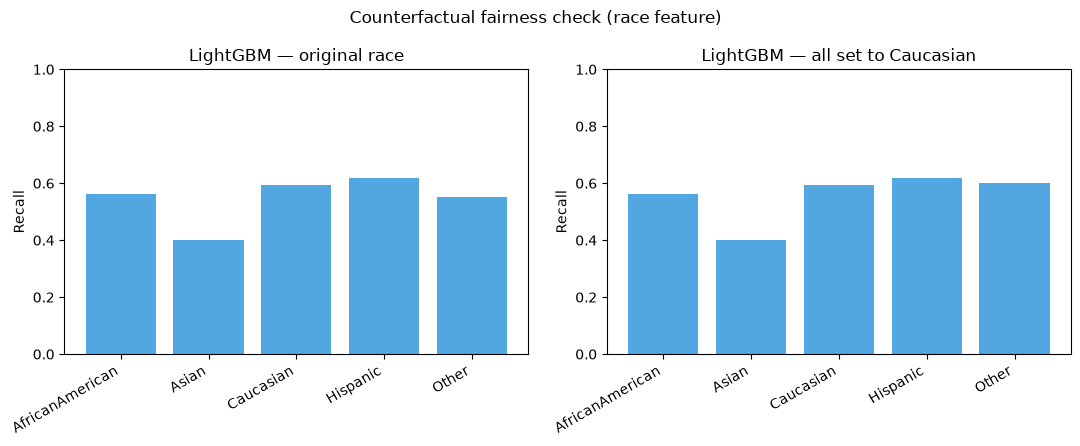

In [15]:
best_yp = best_model.predict(X_test)
best_yp_cf = best_model.predict(X_test_cf)
groups = sorted(sens_test["race"].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (yp, label) in zip(axes, [(best_yp, "original race"), (best_yp_cf, "all set to Caucasian")]):
    recalls = []
    for g in groups:
        mask = sens_test["race"].values == g
        recalls.append(recall_score(y_test[mask], yp[mask]) if mask.sum() and y_test[mask].sum() else 0)
    ax.bar(groups, recalls, color="#3498db", alpha=0.85)
    ax.set_title(f"{best_name} — {label}")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.0)
    ax.set_xticklabels(groups, rotation=30, ha="right")
plt.suptitle("Counterfactual fairness check (race feature)")
plt.tight_layout()
plt.savefig("figures/counterfactual_race.png", dpi=130, bbox_inches="tight")
plt.show()

## Key findings

- All three ensembles land in a similar, modest range (F1 ≈ 0.28, recall
  0.53-0.59) — early readmission is a genuinely hard target from
  administrative data alone; **LightGBM** edges out the others on F1 and
  balanced accuracy.
- SHAP identifies **prior inpatient visits** and **discharge disposition**
  as by far the strongest predictors — both clinically sensible and
  unrelated to demographics, which is a good sign for the model's validity.
- Recall by race ranges from **0.30 (Asian) to 0.62 (Hispanic)** for
  LightGBM — a real gap, though the smallest groups (Asian, Hispanic) have
  the least data and the widest uncertainty. Gender shows no meaningful gap.
- The counterfactual test shows that forcing every patient's `race` to
  `Caucasian` changes **under 1% of predictions** for every model — the
  models are not using race directly. The recall gap therefore comes from
  correlated features (e.g. prior utilization patterns), not the race
  column itself — a proxy-discrimination risk that would need to be
  monitored, not something a "drop the race column" fix would solve.
- **Before any clinical use:** validate on an external hospital/period,
  collect more data for underrepresented groups, and treat the
  race-recall gap as an open fairness issue rather than a solved one.